In [2]:
suppressMessages(library(effects))

ratpup           <- read.table('rat_pup.dat', header=TRUE)
ratpup$sex       <- as.factor(ratpup$sex)
ratpup$litter    <- as.factor(ratpup$litter)
ratpup$treatment <- as.factor(ratpup$treatment)

# Building the Model I
Now that we have established the structure of our data, we can move on to modelling it. For this, we assume that all data wrangling and data exploration has taken place and we are now in a position of wanting to specify a model using `lme()`. In order to do so, we will follow the 3 general steps outlines earlier to build a multilevel model. We will then collapse this to mixed-effects form to fit using `lme()`.

## Modelling a Single Dependency Structure
In our first step, we start by building a model for a *single* dependency structure. With clustered data, the entities that create dependencies are the clusters themselves. These are the *boundaries of dependence*. As such, a *single dependency structure* can be taken to mean a *single cluster*. For this example, this corresponds to a *single litter*. Because we have no sub-clusters within litter, we are at the finest level of dependency and can start here. In doing so, we start by imagining that our data was only collected from a single litter of pups and then examine what form of model could be fit.

## Subsetting the Data
Although possible to conduct this step in a purely theoretical fashion, we can also make it more practical by using `R` to subset the data to just those values from a single litter. For this example, we simply select the label `litter=='1'`. In practice, we should examine multiple litters to make sure we have no accidentally selected an unusual example. For instance, selecting `litter==12` would be a poor start in this dataset (as we will see later).

In [6]:
litter.1 <- subset(ratpup, litter=='1')
print(litter.1)

   pup_id weight    sex litter litsize treatment
1       1   6.60   Male      1      12   Control
2       2   7.40   Male      1      12   Control
3       3   7.15   Male      1      12   Control
4       4   7.24   Male      1      12   Control
5       5   7.10   Male      1      12   Control
6       6   6.04   Male      1      12   Control
7       7   6.98   Male      1      12   Control
8       8   7.05   Male      1      12   Control
9       9   6.95 Female      1      12   Control
10     10   6.29 Female      1      12   Control
11     11   6.77 Female      1      12   Control
12     12   6.57 Female      1      12   Control


Spend a little time studying the output above so you understand the nature of the data we are working with during this step.

````{admonition} Examining Multiple Subsets
A practical point here is that it may be necessary to examine *multiple* subsets before continuing. In the example above, we can see that litter 1 contains 8 male pups and 4 female pups. This is perfectly fine, but imagine if litter 1 contained *all* males or *all* female pups. We may get a biased view of the possible models we could fit to a single litter simply by chance. Instead, it may be worth examining *several* litters to check whether `sex` is indeed constant within litters, or whether it does vary within *some* litters, just not necessarily *all*.
````

## Identifying Suitable Variables
Based on the output above, we can see that `litter`, `litsize` and `treatment` are all *constant* at the level of a single litter. Because of this, we cannot use them as predictors within a single litter. This make sense because these either index the data as a whole (`litter`) or are manipulated *across* litters (`litsize`,`treatment`). So, if we only have *one* litter, these are irrelevant. So, to make this very clear, we can *remove* them from our data for litter 1

In [4]:
litter.1 <- subset(litter.1, select=c(-litter,-litsize,-treatment))
print(litter.1)

    pup_id weight    sex
148    148   6.89 Female
149    149   7.73 Female


We have kept `pup_id`, even though it is somewhat redundant with the row index as there may be cause to identify individual pups at some point later. This may be especially true if the rows get reordered, either intentionally or unintentionally. Either way, it is good practice to keep track of the *units of analysis*. 

## Specifying the Model
Based on the above, the only useable variables we have at the level of a single litter are `weight` and `sex`. So, the only model we can build at the level of a single litter is one that models `weight` as a function of the `sex` of the pup. So, our starting point is the normal linear model

$$
y_{ij} = \mu + \alpha_{j} + \eta_{ij},
$$

where $y_{ij}$ is the value of `weight` for pup $i$ of `sex` $j$, $\mu$ is the average weight of all pups in this litter, $\alpha_{j}$ is the effect of `sex` at level $j$ and $\eta_{ij}$ is the error. This is effectively a one-way ANOVA model of `sex` within a single litter.

### Checking the Data Supports the Model
We can now run this model in `R`. This serves two purposes. Firstly, we can see the syntax we need to model a *single* dependency structure. This will become relevant later when it comes to specifying the mixed-effects model. Secondly, we can check that the model we want is supported by the data that we have. If there are any problems at this stage, it tells us that we will need to constrain our model further as the data does not contain the degree of variation we need.

We fit the model below, making the intercept parameter *explicit* in the formula. The reason for this will become clearer later, but is there to provide a more direct connection with the syntax we will need later on. 

In [5]:
lm.litter.1 <- lm(weight ~ 1 + sex, data=litter.1)
summary(lm.litter.1)

: [1m[33mError[39m in `contrasts<-`:[22m
[33m![39m contrasts can be applied only to factors with 2 or more levels

There are no issues with fitting this model and so no requirement to constrain the model for a single litter further. As expected, `R` has implemented the estimability constraint that $\alpha_{1} = 0$, so $\hat{\mu}$ is now the average value of `weight` for female pups and $\hat{\alpha}_{2}$ is the mean difference between male and female pups. As we can see, in this litter $\hat{\alpha}_{2} = 0.3$, so there is a small increase in `weight` for male pups over female pups. We plot the fit below for completeness, but this is not wholly necessary.

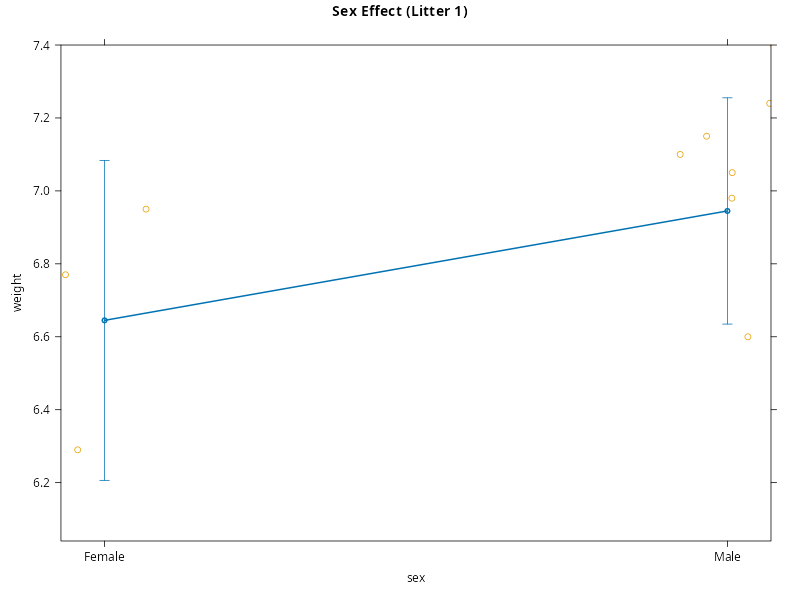

In [ ]:
plot(effect('sex', mod=lm.litter.1, residuals=TRUE), 
     partial.residuals=list(smooth=FALSE), 
     main='Sex Effect (Litter 1)')

[^sextextbook-foot]: It is interesting to note that, in their description of this analysis, [West, Welch & Galecki (2022)](https://www.taylorfrancis.com/books/mono/10.1201/9781003181064/linear-mixed-models-brady-west-kathleen-welch-andrzej-galecki?context=ubx&refId=4dbda113-7f59-4ba9-a710-897ef536cfee) make the decision to fix `sex` to a constant across litters, under the belief that there is a universal effect of `sex` on weight that is not influenced by individual litters.